Figure saved to ../plots/maps_JF12_UF23_R5.png


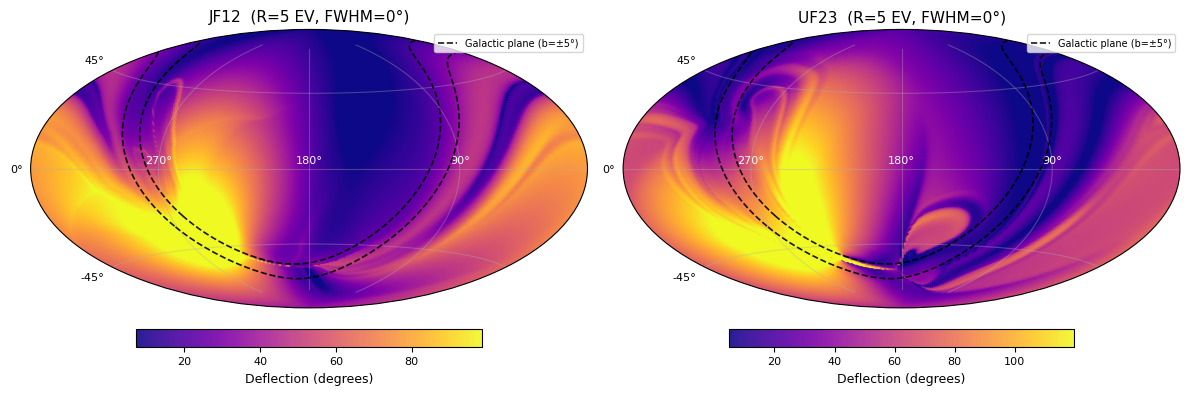

In [1]:
#!/usr/bin/env python3
"""
Self-contained script to plot JF12 and UF23 GMF deflection maps side by side.

Requires:
  - numpy, matplotlib, healpy, astropy
  - Deflection data files (paths defined in Config below)
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.ticker import FormatStrFormatter
import healpy as hp
from astropy.io import ascii


# ----------------------------- Configuration -----------------------------
class Config:
    """Paths and parameters for the deflection maps."""
    # Deflection file paths
    DEFL_FILES = {
        "JF12":   "../data/deflexiones_R2R5R8_final.txt",
        "UF23":   "../data/deflexiones_R2R5R8_final_UF23Field.txt",
    }
    RIGIDITY = 5          # rigidity in EV
    FWHM_DEG = 0.0       # smoothing FWHM (degrees)
    PLOT_SAVE = "../plots/maps_JF12_UF23_R5.png"   # output path


# ------------------------ Helper: Galactic plane -------------------------
def galactic_plane_lines(b_vals=(5, -5), n=1000):
    """
    Return (ra_hammer, dec_rad) arrays for Galactic latitude contours,
    with NaN breaks at RA wrap‑arounds.
    """
    try:
        from astropy.coordinates import SkyCoord
        import astropy.units as u
    except ImportError:
        return []

    l = np.linspace(0, 360, n)
    lines = []
    for b_val in b_vals:
        coords = SkyCoord(l=l*u.degree, b=b_val*u.degree,
                          frame='galactic').transform_to('fk5')
        ra_line = coords.ra.degree
        dec_line = coords.dec.degree
        # Convert to Hammer projection coordinates
        ra_h = np.radians(-ra_line + 180.0)
        dec_h = np.radians(dec_line)
        # Insert NaNs at large jumps to break the line
        diff = np.abs(np.diff(ra_h))
        jump_idx = np.where(diff > 5.0)[0] + 1
        ra_plot = np.insert(ra_h, jump_idx, np.nan)
        dec_plot = np.insert(dec_h, jump_idx, np.nan)
        lines.append((ra_plot, dec_plot))
    return lines


# ------------------------- Load deflection map ---------------------------
def load_deflection_map(rigidity, defl_file, fwhm_deg):
    """Load and optionally smooth a deflection map."""
    data = ascii.read(defl_file)
    # Determine pixel IDs (assume 'pixid' column exists; fallback to index)
    if 'pixid' in data.colnames:
        pixel_ids = np.asarray(data['pixid'], dtype=int)
    else:
        pixel_ids = np.arange(len(data))

    defl_data = np.asarray(data[f'deflexion(deg)_R{int(rigidity)}'], dtype=float)
    npix = int(np.max(pixel_ids)) + 1
    nside = hp.npix2nside(npix)
    dmap = np.full(npix, hp.UNSEEN, dtype=float)
    dmap[pixel_ids] = defl_data

    if fwhm_deg and fwhm_deg > 0:
        dmap = hp.smoothing(dmap, fwhm=np.radians(fwhm_deg), verbose=False)

    return dmap, nside


# ------------------------- Plot helper -----------------------------------
def draw_map_on_ax(ax, dmap, model_label, fwhm_deg, rigidity):
    """Draw a smoothed deflection map on a Hammer Axes."""
    mask = dmap != hp.UNSEEN
    npix = len(dmap)
    nside = hp.npix2nside(npix)

    theta, phi = hp.pix2ang(nside, np.arange(npix)[mask])
    dec = 90 - np.degrees(theta)
    ra = np.degrees(phi)

    vmin = np.percentile(dmap[mask], 5)
    vmax = np.percentile(dmap[mask], 95)

    # Hammer projection coordinates
    ra_h = np.radians(-ra + 180.0)
    dec_h = np.radians(dec)

    sc = ax.scatter(ra_h, dec_h, c=dmap[mask], s=6, cmap='plasma',
                    norm=mcolors.Normalize(vmin=vmin, vmax=vmax),
                    edgecolor='none', alpha=0.9, rasterized=True)

    # Galactic plane lines
    for i, (ra_line, dec_line) in enumerate(galactic_plane_lines()):
        lbl = 'Galactic plane (b=±5°)' if i == 0 else '_nolegend_'
        ax.plot(ra_line, dec_line, 'k--', lw=1.2, alpha=0.9, label=lbl)

    # Axes cosmetics
    xticks_deg = [270, 180, 90]
    ax.set_xticks(-np.radians(xticks_deg) + np.pi)
    ax.set_xticklabels([f'{d}°' for d in xticks_deg], fontsize=8)
    ax.tick_params(axis='x', labelcolor='white')
    ax.set_yticks(np.radians([-45, 0, 45]))
    ax.set_yticklabels(['-45°', '0°', '45°'], fontsize=8)
    ax.grid(True, alpha=0.35)
    ax.set_title(f'{model_label}  (R={rigidity} EV, FWHM={fwhm_deg:.0f}°)', fontsize=11)

    # Colorbar
    cbar = plt.colorbar(sc, ax=ax, orientation='horizontal',
                        pad=0.05, fraction=0.04, shrink=0.85)
    cbar.set_label('Deflection (degrees)', fontsize=9)
    cbar.ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    cbar.ax.tick_params(labelsize=8)

    ax.legend(loc='upper right', fontsize=7)


# ----------------------------- Main --------------------------------------
def main():
    """Create the side‑by‑side JF12 / UF23 deflection map figure."""
    models = ['JF12', 'UF23']
    fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                             subplot_kw={'projection': 'hammer'})

    for ax, model in zip(axes, models):
        defl_file = Config.DEFL_FILES[model]
        dmap, _ = load_deflection_map(
            rigidity=Config.RIGIDITY,
            defl_file=defl_file,
            fwhm_deg=Config.FWHM_DEG,
        )
        draw_map_on_ax(ax, dmap, model, Config.FWHM_DEG, Config.RIGIDITY)

    plt.tight_layout()
    if Config.PLOT_SAVE:
        plt.savefig(Config.PLOT_SAVE, dpi=200, bbox_inches='tight')
        print(f"Figure saved to {Config.PLOT_SAVE}")
    plt.show()


if __name__ == '__main__':
    main()